In [42]:
import pandas as pd
import re
import pymorphy2
from collections import defaultdict, Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Инициализация морфологического анализатора
morph = pymorphy2.MorphAnalyzer()

In [4]:
authorities = [
    "Министерство иностранных дел Республики Казахстан",
    "Министерство внутренних дел Республики Казахстан",
    "Министерство обороны Республики Казахстан",
    "Министерство культуры и информации Республики Казахстан",
    "Министерство сельского хозяйства Республики Казахстан",
    "Министерство юстиции Республики Казахстан",
    "Министерство просвещения Республики Казахстан",
    "Министерство науки и высшего образования Республики Казахстан",
    "Министерство здравоохранения Республики Казахстан",
    "Министерство труда и социальной защиты населения Республики Казахстан",
    "Министерство промышленности и строительства Республики Казахстан",
    "Министерство финансов Республики Казахстан",
    "Министерство туризма и спорта Республики Казахстан",
    "Министерство национальной экономики Республики Казахстан",
    "Министерство цифрового развития, инноваций и аэрокосмической промышленности Республики Казахстан",
    "Министерство энергетики Республики Казахстан",
    "Министерство торговли и интеграции Республики Казахстан",
    "Министерство экологии и природных ресурсов Республики Казахстан",
    "Министерство по чрезвычайным ситуациям Республики Казахстан",
    "Министерство транспорта Республики Казахстан",
    "Генеральная прокуратура Республики Казахстан",
    "Верховный суд Республики Казахстан",
    "Акимат"

    # аббревиатуры
    "ГП", "МСХ", "МЮ", "МОН", "МЗ", "МТСЗН", "МИОР", "МЦРИАП", "МИИР", "МФ",
    "МО", "МКС", "МНЭ", "МЭ", "МИД", "МВД", "МЭГПР", "МТИ", "АДГС", "НБ",
    "КПССУ ГП", "ККМФД МЗСР", "КНБ", "ДОДСВС", "ЕНПФ", "МИО",
    "Государственная корпорация", "АГУ", "АО", "РГУ", "РГП",
    "РГП на ПХВ", "РГКП", "КГУ", "СМИ", "АРРФР"
]

areas = [
    # Области
    "Абайская область", "Акмолинская область", "Актюбинская область",
    "Алматинская область", "Атырауская область", "Восточно-Казахстанская область",
    "Жамбылская область", "Жетысуская область", "Западно-Казахстанская область",
    "Карагандинская область", "Костанайская область", "Кызылординская область",
    "Мангистауская область", "Павлодарская область", "Северо-Казахстанская область",
    "Туркестанская область", "Улытауская область",

    # аббревиатуры
    "СКО", "ВКО", "ЗКО", "ЮКО",

    # Административные центры (города)
    "Актау", "Актобе", "Атырау", "Жезказган", "Караганда",
    "Кокшетау", "Конаев", "Костанай", "Кызылорда", "Павлодар",
    "Петропавловск", "Семей", "Талдыкорган", "Тараз",
    "Туркестан", "Уральск", "Усть-Каменогорск",

    # Города республиканского значения
    "Астана", "Алматы", "Шымкент"
]
keywords = authorities + areas
all_results = []

In [5]:
dataset = pd.DataFrame(columns=["Date"] + keywords)

# Инициализация pymorphy2
morph = pymorphy2.MorphAnalyzer()
# Генерация всех форм ключевых слов
def generate_forms(word):
    parsed = morph.parse(word)[0]
    return {form.word for form in parsed.lexeme}
# Генерируем формы для ключевых слов
keyword_forms = {}
for keyword in keywords:
    keyword_forms[keyword.lower()] = generate_forms(keyword.lower())
# Объединяем все формы в один набор
all_keyword_forms = set()
for forms in keyword_forms.values():
    all_keyword_forms.update(forms)
# Функция подсчёта общего количества вхождений ключевых слов
def find_total_keyword_occurrences(text):
    tokens = re.findall(r'\b\w+\b', text.lower())  # Извлекаем только слова
    lemmatized_tokens = [morph.parse(token)[0].normal_form for token in tokens]  # Лемматизация

    # Подсчитываем общее количество вхождений ключевых слов
    word_count = defaultdict(int)
    for word in lemmatized_tokens:
        if word in all_keyword_forms:
            word_count[word] += 1  # Увеличиваем счётчик для каждого вхождения

    return word_count


In [17]:
# Загрузка ссылок из CSV
df = pd.read_csv("news_text_all.csv")
total_links = len(df)
chunk_size = total_links // 5  # Делим на 5 частей

# Укажите начальный индекс для итерации
start_index = chunk_size * 4 # Изменяйте при каждом запуске

# Парсинг ссылок
all_results = []

https://crb-sarkand.kz/ru/content/reestr-gosudarstvennyh-uslug#:~:text=%D0%9C%D0%98%D0%9E%D0%A0%20%E2%80%93%20%D0%9C%D0%B8%D0%BD%D0%B8%D1%81%D1%82%D0%B5%D1%80%D1%81%D1%82%D0%B2%D0%BE%20%D0%B8%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%B8%20%D0%B8%20%D0%BE%D0%B1%D1%89%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE,%D0%9C%D0%A4%20%2D%20%D0%9C%D0%B8%D0%BD%D0%B8%D1%81%D1%82%D0%B5%D1%80%D1%81%D1%82%D0%B2%D0%BE%20%D1%84%D0%B8%D0%BD%D0%B0%D0%BD%D1%81%D0%BE%D0%B2%20%D0%A0%D0%B5%D1%81%D0%BF%D1%83%D0%B1%D0%BB%D0%B8%D0%BA%D0%B8%20%D0%9A%D0%B0%D0%B7%D0%B0%D1%85%D1%81%D1%82%D0%B0%D0%BD

In [18]:
# for index, row in df.iterrows():
for index, row in df.iloc[start_index:start_index + chunk_size].iterrows():
    # Подсчитываем ключевые слова
    keyword_counts = find_total_keyword_occurrences(row["Text"])

    # Формируем результаты
    result = {"Дата": row["Date"]}
    for keyword in keywords:
        result[keyword] = keyword_counts.get(keyword.lower(), 0)

    all_results.append(result)


# Сохраняем результаты в CSV
iteration_number = start_index // chunk_size + 1
output_file = f"area_part{iteration_number}.csv"
results_df = pd.DataFrame(all_results)
results_df.to_csv(output_file, index=False, encoding='utf-8')
print(f"Результаты сохранены в '{output_file}'")

Результаты сохранены в 'area_part5.csv'


In [30]:
df = pd.DataFrame()
for i in range(1, 6):
  part = pd.read_csv(f"area_part{i}.csv")
  df = pd.concat([df, part])

In [31]:
df.to_csv("area_all.csv", index=False)

In [34]:
# Преобразуем столбец с датами в формат datetime
df['Дата'] = pd.to_datetime(df['Дата'])

# Устанавливаем столбец Date как индекс
df.set_index('Дата', inplace=True)

# Группируем по месяцам и суммируем значения для каждого ключевого слова
monthly_data = df.resample('M').sum()

# Сохраняем результаты в новый CSV файл
monthly_data.to_csv('monthly_data.csv')

print("Результаты успешно сохранены в 'monthly_data.csv'")

Результаты успешно сохранены в 'monthly_data.csv'


<ipython-input-34-5474882cd85b>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df.resample('M').sum()


In [36]:
df = pd.read_csv("monthly_data.csv")

In [40]:
df = df.replace(0, np.nan)
df.isna().sum()

,0
Дата,0
Министерство иностранных дел Республики Казахстан,97
Министерство внутренних дел Республики Казахстан,97
Министерство обороны Республики Казахстан,97
Министерство культуры и информации Республики Казахстан,97
...,...
Уральск,72
Усть-Каменогорск,97
Астана,18
Алматы,15


In [41]:
df_null = df[df.isna().sum()[df.isna().sum() > 0].index]
df_not_null = df[df_null.columns].notnull().sum()
print("Количество нулевых значений")
df.isna().sum()[df.isna().sum() > 0]

Количество нулевых значений


,0
Министерство иностранных дел Республики Казахстан,97
Министерство внутренних дел Республики Казахстан,97
Министерство обороны Республики Казахстан,97
Министерство культуры и информации Республики Казахстан,97
Министерство сельского хозяйства Республики Казахстан,97
...,...
Уральск,72
Усть-Каменогорск,97
Астана,18
Алматы,15


<ipython-input-44-bafce99e7c86>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_words'] = df.drop(columns="Дата").sum(axis=1)


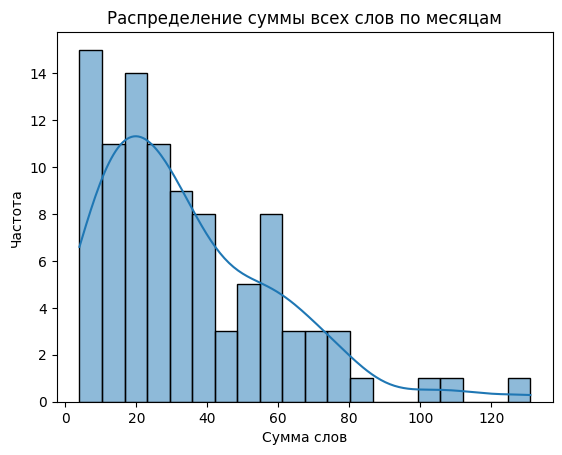

In [44]:
# Суммируем все значения по строкам (то есть по всем ключевым словам)
df['total_words'] = df.drop(columns="Дата").sum(axis=1)

# Создаем график гистограммы (histplot)
sns.histplot(df['total_words'], kde=True, bins=20)

# Настроим отображение графика
plt.title('Распределение суммы всех слов по месяцам')
plt.xlabel('Сумма слов')
plt.ylabel('Частота')
plt.show()

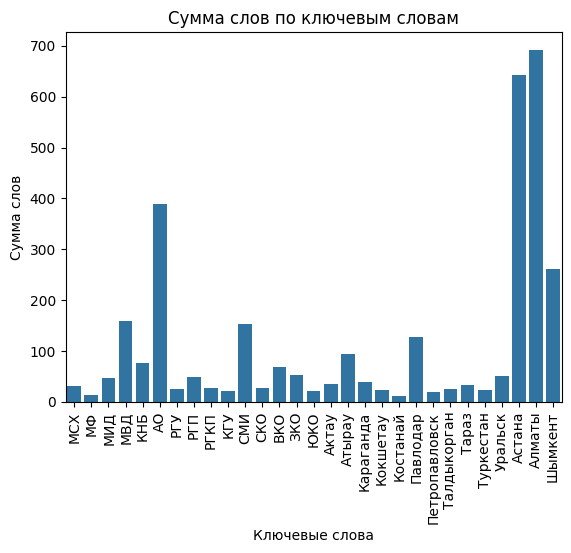

In [49]:
# Чтение нового CSV файла с агрегированными данными
df = pd.read_csv('monthly_data.csv')

# Определяем пороговое значение для удаления столбцов
threshold = len(df) * 0.1
df = df.replace(0, np.nan)

# Удаляем столбцы, где количество NaN больше порогового значения
df = df.dropna(axis=1, thresh=threshold)

# Убираем столбец с датой, так как он нам не нужен
df_keywords = df.drop(columns='Дата')

# Суммируем значения по каждому ключевому слову (столбцу)
keyword_sums = df_keywords.sum()

# Создаем график гистограммы (barplot)
sns.barplot(x=keyword_sums.index, y=keyword_sums.values)

# Настроим отображение графика
plt.title('Сумма слов по ключевым словам')
plt.xlabel('Ключевые слова')
plt.ylabel('Сумма слов')
plt.xticks(rotation=90)  # Поворачиваем метки по оси X для лучшего отображения
plt.show()